Course link: https://www.youtube.com/watch?v=a4HBKEda_F8

# 1. Introdcution
The course is structured in two parts: 
1. Essential Elasticsearch fundamentals: index management, document storage, text analysis, pipeline creation, search functionality, and advanced features like semantic search and embeddings.

2. A practical section where you'll build a real-world website using Elasticsearch as a search engine, working with the Astronomy Picture of the Day (APOD) dataset to implement features such as data cleaning pipelines, tokenization, pagination, and aggregations.


# 2. Installation

1. Make sure docker is installed: https://www.docker.com/
2. Go to the following site and copy the command onto cmd: https://www.elastic.co/search-labs/tutorials/install-elasticsearch/docker


* Linux:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch \
    -e "discovery.type=single-node" \
    -e "xpack.security.enabled=false" \
    -e "xpack.license.self_generated.type=trial" \
    -v "elasticsearch-data:/usr/share/elasticsearch/data" \
    docker.elastic.co/elasticsearch/elasticsearch:8.15.0


* Windows:\
  docker run -p 127.0.0.1:9200:9200 -d --name elasticsearch -e "discovery.type=single-node" -e "xpack.security.enabled=false" -e "xpack.license.self_generated.type=trial" -v "elasticsearch-data:/usr/share/elasticsearch/data" docker.elastic.co/elasticsearch/elasticsearch:8.15.0




check your container is up and running in http://localhost:9200.

* To stop and remove it, run this in cmd: **docker stop elasticsearch docker rm elasticsearch**
* To stop it but keep it (so you can restart it later): **docker stop elasticsearch**
  Then restart it with: **docker start elasticsearch**
* Check status anytime with: **docker ps -a**
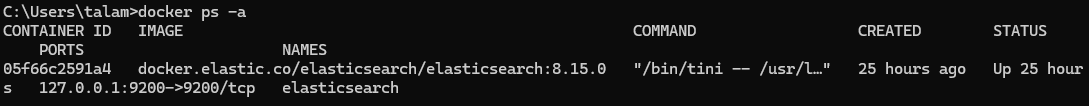

In [1]:
# run this cell to install the necessary dependencies
%pip install "elasticsearch<9"

Note: you may need to restart the kernel to use updated packages.


# 3. Create an Index

## Definitions:
* **Index**: collection of documents that share similar characteristics.
    Can be compared to datasbase in a relational database (i.e. SQL) and optimized for searching large volumes of textual, numeric and structured data.
* **Shard**: a partition of an index. The index is divided into multiple shards, and each shard stores a subset of the documents. This allows data to be distributed across nodes and queries to be executed in parallel.
    Elasticsearch knows how to reconstruct the documents to find the information we need.

* **Replica**: a copy of the data (i.e., replica=1 means each shard is duplicated once). Each replica shard has the same data and structure as its primary shard. Replicas are used for system resilience (fault tolerance) and for improving search performance by allowing parallel searches.

In [ ]:
from elasticsearch import Elasticsearch
from pprint import pprint

# Connect to Elasticsearch
es = Elasticsearch("http://localhost:9200")

# Check if the connection is successful
if es.ping():
    print("Connected to Elasticsearch!")

    # Get and print cluster information
    info = es.info()
    pprint(info)
else:
    print("Connection failed.")

Connected to Elasticsearch!
ObjectApiResponse({'name': '05f66c2591a4', 'cluster_name': 'docker-cluster', 'cluster_uuid': 'Yn5zjAt7TUOntAMcWpLSeg', 'version': {'number': '8.15.0', 'build_flavor': 'default', 'build_type': 'docker', 'build_hash': '1a77947f34deddb41af25e6f0ddb8e830159c179', 'build_date': '2024-08-05T10:05:34.233336849Z', 'build_snapshot': False, 'lucene_version': '9.11.1', 'minimum_wire_compatibility_version': '7.17.0', 'minimum_index_compatibility_version': '7.0.0'}, 'tagline': 'You Know, for Search'})


In [4]:
# deleting the index if it already exists
if es.indices.exists(index="my_index"):
    es.indices.delete(index="my_index")
    print("Index 'my_index' deleted.")

# creating an index
index_name = "my_index"
if not es.indices.exists(index=index_name):
    # create the index + change settings: shards and replicas
    es.indices.create(index=index_name, body={"settings": {"number_of_shards": 3, "number_of_replicas": 2}})

    # print the response + check index settings
    response = es.indices.get(index=index_name)
    pprint(response)
else:    
    print(f"Index '{index_name}' already exists.")
    

Index 'my_index' deleted.
ObjectApiResponse({'my_index': {'aliases': {}, 'mappings': {}, 'settings': {'index': {'routing': {'allocation': {'include': {'_tier_preference': 'data_content'}}}, 'number_of_shards': '3', 'provided_name': 'my_index', 'creation_date': '1773243703120', 'number_of_replicas': '2', 'uuid': 'h3Sd8YC6TWafLknSD-yygw', 'version': {'created': '8512000'}}}}})


# 4. Inserting Documents

## Definitions:
* **Mapping**: the process elasticsearch does in order to automatically detect the types of the fields in the document.

**Note**: manual mappping should be done in the creation of the index and before inserting any documents.
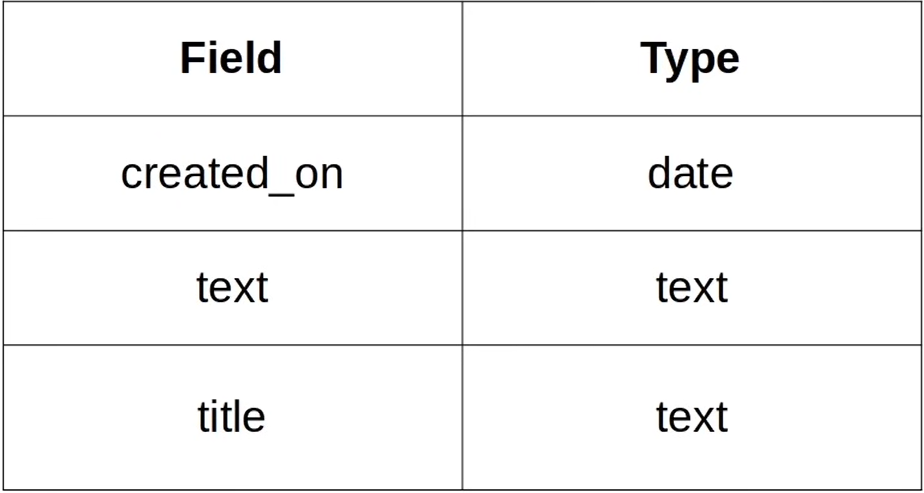

**Note**: all documents have to be in a JSON format and with the same fields in order to add them to the index.

### adding an example document to the index

In [ ]:

doc = {
    'title': 'Elasticsearch Basics',
    'text': 'This is a basic introduction to Elasticsearch.',
    'created_on': '2024-06-01'
}

response = es.index(index=index_name, body=doc)
print("Document indexed:", response['result'])

Document indexed: created


In [7]:
# printing other information about the indexed document
print("Document ID:", response['_id'])
print("Index:", response['_index'])
print("Shards:", response['_shards'])

Document ID: g1-a3ZwBrkuJS2iOrxTu
Index: my_index
Shards: {'total': 3, 'successful': 1, 'failed': 0}


### Insertinng multiple documents

In [ ]:

docs = [
    {'title': 'Elasticsearch Advanced', 'text': 'This is an advanced guide to Elasticsearch.', 'created_on': '2024-06-02'},
    {'title': 'Elasticsearch Querying', 'text': 'Learn how to query Elasticsearch effectively.', 'created_on': '2024-06-03'},
    {'title': 'Elasticsearch Scaling', 'text': 'Best practices for scaling Elasticsearch clusters.', 'created_on': '2024-06-04'}
]

# define functions
def insert_document(document):
    response = es.index(index=index_name, body=document)
    return response

def print_info(response):
    print(f"""Document ID: {response['_id']} is {response['result']} in index: {response['_index']} and is split into {response['_shards']['total']} shards.""")
    

# insert documents and print info
for doc in docs:
    response = insert_document(doc)
    print_info(response)


Document ID: hF-l3ZwBrkuJS2iOBhTJ is 
          created in index: my_index and is split into 3 shards.
Document ID: hV-l3ZwBrkuJS2iOBxQB is 
          created in index: my_index and is split into 3 shards.
Document ID: hl-l3ZwBrkuJS2iOBxQ- is 
          created in index: my_index and is split into 3 shards.


In [10]:
# Showing the elasticsearch mapping
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


### Manual mapping

In [ ]:

mapping = {
    "properties": {
        "title": {"type": "text",
            'fields': {
                'keyword': {
                    'type': 'keyword',
                    'ignore_above': 256
                    }
            }},
        "text": {"type": "text",
                 'fields': {
                     'keyword': {
                            'type': 'keyword',
                            'ignore_above': 256
                         }
                 }},
        "created_on": {"type": "date"}
    }
}

es.indices.put_mapping(index=index_name, body=mapping)
mapping = es.indices.get_mapping(index=index_name)
pprint(mapping[index_name]['mappings']['properties'])

{'created_on': {'type': 'date'},
 'text': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
          'type': 'text'},
 'title': {'fields': {'keyword': {'ignore_above': 256, 'type': 'keyword'}},
           'type': 'text'}}


## 5. Field Data Types

* **Binary**: